---
# 1. Import Modules 
<span id="Importmodules"></span>

---

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import joblib
import tensorflow as tf
import os
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

def split_data(input_folder, output_folder, test_size=0.2):
    """
    Splits the data in the input folder into train and test sets and saves them in the output folder.

    Parameters:
        input_folder (str): Path to the folder containing the dataset.
        output_folder (str): Path to save the train and test datasets.
        test_size (float): Proportion of the dataset to include in the test split.
    """
    # Create output folders for train and test
    train_folder = os.path.join(output_folder, 'train')
    test_folder = os.path.join(output_folder, 'test')

    os.makedirs(train_folder, exist_ok=True)
    os.makedirs(test_folder, exist_ok=True)

    # Iterate through each class folder
    for class_name in os.listdir(input_folder):
        class_folder = os.path.join(input_folder, class_name)

        if os.path.isdir(class_folder):
            # Get all files in the class folder
            files = [f for f in os.listdir(class_folder) if os.path.isfile(os.path.join(class_folder, f))]

            # Split files into train and test
            train_files, test_files = train_test_split(files, test_size=test_size, random_state=42)

            # Create class folders in train and test directories
            train_class_folder = os.path.join(train_folder, class_name)
            test_class_folder = os.path.join(test_folder, class_name)

            os.makedirs(train_class_folder, exist_ok=True)
            os.makedirs(test_class_folder, exist_ok=True)

            # Copy files to train and test folders
            for file in train_files:
                shutil.copy(os.path.join(class_folder, file), os.path.join(train_class_folder, file))

            for file in test_files:
                shutil.copy(os.path.join(class_folder, file), os.path.join(test_class_folder, file))

    print(f"Data split completed. Train and test sets saved in '{output_folder}'.")

# Example usage
input_folder = "asl_dataset"  # Replace with the path to your folder containing images
output_folder = "split_data"      # Replace with the path to save train and test folders
test_size = 0.1                     

split_data(input_folder, output_folder, test_size)


In [3]:
# Load and preprocess the dataset
train_dir = 'split_data/train'
test_dir = 'split_data/test'

In [4]:
# ImageDataGenerator for loading and augmenting images
datagen = ImageDataGenerator(rescale=1./255)

---
# 2. Load images with augmentation
<span id="Importmodules"></span>

---

In [5]:
# Load images from the training directory
train_data_gen = datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

# Load images from the testing directory
test_data_gen = datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

# Step 1: Load MobileNet as a feature extractor
base_model = MobileNet(weights='imagenet', include_top=False)

# Add a Global Average Pooling layer to extract features
x = base_model.output
x = GlobalAveragePooling2D()(x)
feature_extractor = Model(inputs=base_model.input, outputs=x)

# Freeze the layers of MobileNet to use it as a feature extractor
for layer in base_model.layers:
    layer.trainable = False

# Step 2: Extract features for training and testing data
def extract_features(data_generator):
    features = []
    labels = []
    
    # Loop through batches of images and extract features
    for images, batch_labels in data_generator:
        # Extract features from the MobileNet model
        feature_batch = feature_extractor.predict(images)
        features.append(feature_batch)
        labels.append(batch_labels)
        
        # If we have enough data, stop
        if len(features) * data_generator.batch_size >= data_generator.samples:
            break
    
    # Convert to numpy arrays
    features = np.vstack(features)
    labels = np.vstack(labels)
    return features, labels

# Extract features for train data
X_train_features, y_train_labels = extract_features(train_data_gen)

# Extract features for test data
X_test_features, y_test_labels = extract_features(test_data_gen)

# Step 3: Save the extracted features to .joblib files
joblib.dump((X_train_features, y_train_labels), 'train.joblib')
joblib.dump((X_test_features, y_test_labels), 'test.joblib')

# Step 4: Split the training data into training and validation sets (80% training, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_features, y_train_labels, test_size=0.2, random_state=42
)

# Optionally, save the split data to .joblib files
joblib.dump((X_train, y_train), 'train_split.joblib')
joblib.dump((X_val, y_val), 'val_split.joblib')

# Saved in 'train.joblib' and 'test.joblib'
print("Features extracted and saved to 'train.joblib' and 'test.joblib'.")

Found 1632 images belonging to 26 classes.
Found 183 images belonging to 26 classes.


1/1 [==============================] - 1s 918ms/step
Features extracted and saved to 'train.joblib' and 'test.joblib'.


---
# 3. Mobilenet Model
<span id="Importmodules"></span>

---

In [6]:
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout,GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
import seaborn as sns
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input


# Load the features extracted previously
X_train_features, y_train_labels = joblib.load('train_split.joblib')
X_val, y_val = joblib.load('val_split.joblib')
X_test_features, y_test_labels = joblib.load('test.joblib')

# If the labels are not already one-hot encoded, we can one-hot encode them
num_classes = y_train_labels.shape[1]  

input_shape = X_train_features.shape[1]  # The number of features per sample (1024 in this case)

# Define the model for classification
input_layer = Input(shape=(input_shape,))  # This is the shape of the features (1024,)
x = Dropout(0.5)(input_layer)  # Dropout to reduce overfitting
x = Dense(1024, activation='relu')(x)  # Fully connected layer with ReLU activation
x = Dropout(0.5)(x)  # Another Dropout layer
output_layer = Dense(num_classes, activation='softmax')(x)  # Output layer with softmax for multi-class classification

# Create the model
model = Model(inputs=input_layer, outputs=output_layer)

# Compile the model
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train_features, y_train_labels, 
                    epochs=5, batch_size=32, 
                    validation_data=(X_val, y_val))


Epoch 1/5


41/41 [==============================] - 3s 28ms/step - loss: 2.4245 - accuracy: 0.3333 - val_loss: 0.7610 - val_accuracy: 0.8502
Epoch 2/5
41/41 [==============================] - 1s 21ms/step - loss: 0.9519 - accuracy: 0.7172 - val_loss: 0.3407 - val_accuracy: 0.9144
Epoch 3/5
41/41 [==============================] - 1s 23ms/step - loss: 0.5265 - accuracy: 0.8437 - val_loss: 0.1843 - val_accuracy: 0.9602
Epoch 4/5
41/41 [==============================] - 1s 24ms/step - loss: 0.4283 - accuracy: 0.8544 - val_loss: 0.1400 - val_accuracy: 0.9694
Epoch 5/5
41/41 [==============================] - 1s 22ms/step - loss: 0.3222 - accuracy: 0.8996 - val_loss: 0.1351 - val_accuracy: 0.9755


In [7]:
# Save the trained model
model.save('mobilenet_v2_classifier_model.h5')

---
# 4. Plot training and validation accuracy
<span id="Importmodules"></span>

---

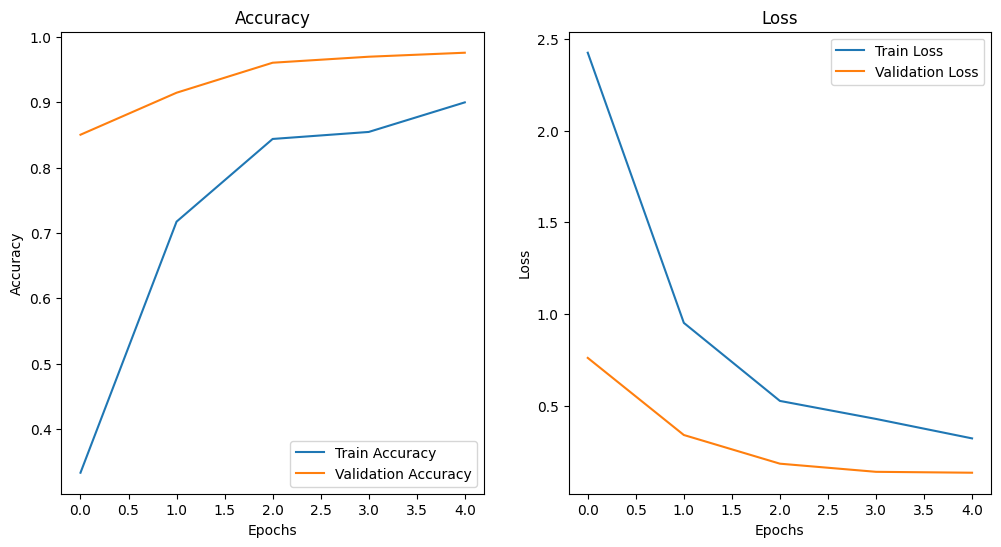

In [8]:
# Plot accuracy and loss
plt.figure(figsize=(12, 6))

# Plot training & validation accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [9]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test_features, y_test_labels, verbose=1)
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test loss: {test_loss:.4f}")

# Make predictions on the test set
y_pred = model.predict(X_test_features)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test_labels, axis=1)

6/6 [==============================] - 0s 4ms/step - loss: 0.0666 - accuracy: 0.9891
Test accuracy: 0.9891
Test loss: 0.0666
6/6 [==============================] - 0s 3ms/step


---
# 5. Confusion Matrix and Classification Report
<span id="Importmodules"></span>

---

Confusion Matrix:
[[7 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 7 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 7 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 7 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 7 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 7 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 7 0 0 0 0 0

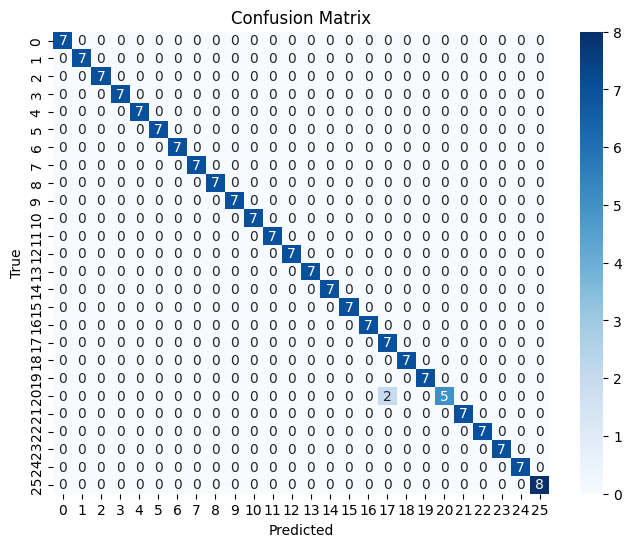

In [10]:

# Confusion Matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)
print("Confusion Matrix:")
print(conf_matrix)

# Classification Report
class_report = classification_report(y_true_classes, y_pred_classes)
print("Classification Report:")
print(class_report)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.arange(num_classes), yticklabels=np.arange(num_classes))
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

---
# 6. CNN Model
<span id="Importmodules"></span>

---

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import joblib
import numpy as np

# Load the features and labels for train, validation, and test sets
X_train_features, y_train_labels = joblib.load('train_split.joblib')
X_val, y_val = joblib.load('val_split.joblib')
X_test_features, y_test_labels = joblib.load('test.joblib')

# Print the shape of the features to confirm
print(f"X_train_features shape: {X_train_features.shape}")
print(f"y_train_labels shape: {y_train_labels.shape}")
print(f"X_test_features shape: {X_test_features.shape}")
print(f"y_test_labels shape: {y_test_labels.shape}")

# Define the fully connected model for the extracted features
model = Sequential()

# Input layer (feature vectors of size 1024)
model.add(Dense(1024, activation='relu', input_shape=(X_train_features.shape[1],)))
model.add(Dropout(0.5))  # Dropout to reduce overfitting

# Hidden layers
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

# Output layer (number of classes)
model.add(Dense(y_train_labels.shape[1], activation='softmax'))

# Compile the model
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train_features, y_train_labels, 
                    epochs=10, batch_size=32, 
                    validation_data=(X_val, y_val))

X_train_features shape: (1305, 1024)
y_train_labels shape: (1305, 26)
X_test_features shape: (183, 1024)
y_test_labels shape: (183, 26)
Epoch 1/10
41/41 [==============================] - 2s 34ms/step - loss: 3.3057 - accuracy: 0.0866 - val_loss: 2.6009 - val_accuracy: 0.4679
Epoch 2/10
41/41 [==============================] - 1s 30ms/step - loss: 2.4924 - accuracy: 0.2299 - val_loss: 1.4792 - val_accuracy: 0.5902
Epoch 3/10
41/41 [==============================] - 1s 31ms/step - loss: 1.7083 - accuracy: 0.4330 - val_loss: 0.8190 - val_accuracy: 0.7706
Epoch 4/10
41/41 [==============================] - 1s 30ms/step - loss: 1.1356 - accuracy: 0.6115 - val_loss: 0.4938 - val_accuracy: 0.8593
Epoch 5/10
41/41 [==============================] - 1s 30ms/step - loss: 0.8386 - accuracy: 0.7042 - val_loss: 0.3540 - val_accuracy: 0.8899
Epoch 6/10
41/41 [==============================] - 1s 31ms/step - loss: 0.6190 - accuracy: 0.7816 - val_loss: 0.2246 - val_accuracy: 0.9480
Epoch 7/10
41/41 [

In [12]:
# Save the model
model.save('cnn_model.h5')

In [13]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test_features, y_test_labels)
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test loss: {test_loss:.4f}")

6/6 [==============================] - 0s 3ms/step - loss: 0.0414 - accuracy: 0.9891
Test accuracy: 0.9891
Test loss: 0.0414


---
# 7. Plot training and validation accuracy
<span id="Importmodules"></span>

---

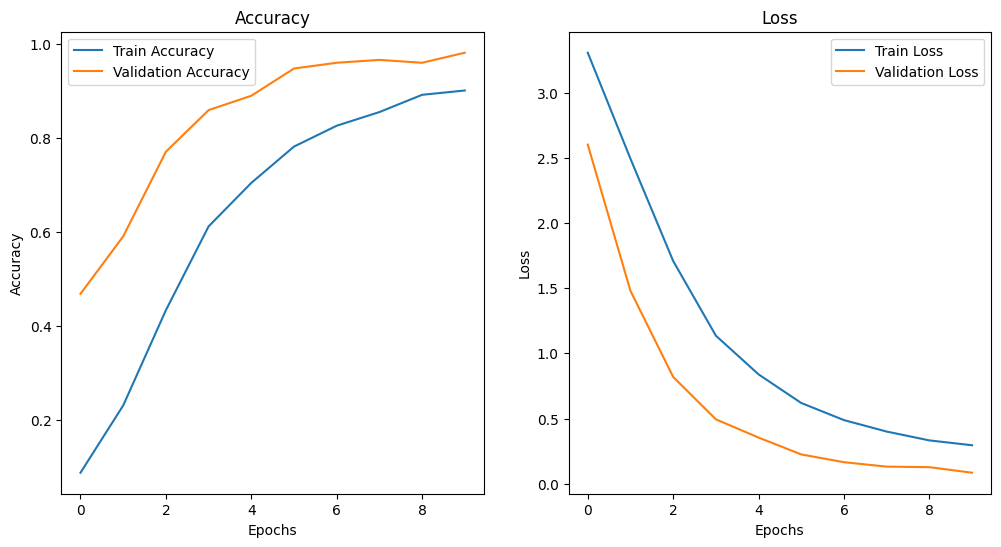

In [14]:
# Plot accuracy and loss
plt.figure(figsize=(12, 6))

# Plot training & validation accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

---
# 8. Confusion Matrix and Classification Report
<span id="Importmodules"></span>

---

6/6 [==============================] - 0s 6ms/step
Confusion Matrix:
[[7 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 7 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 2 5 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 7 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 7 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 7 0 0 0 0 0 0 0 0

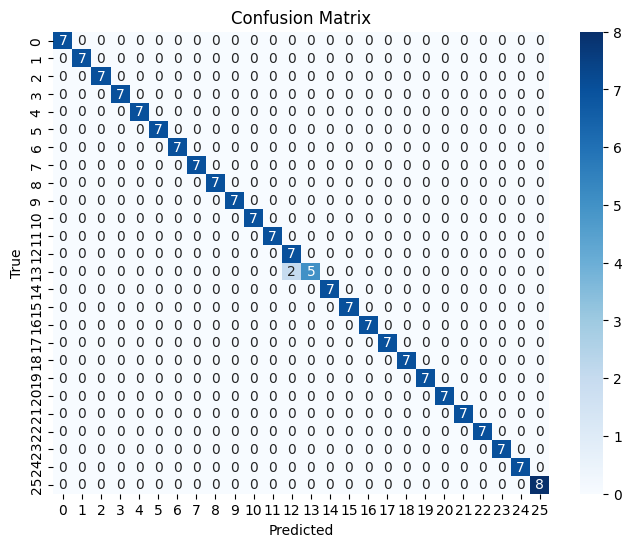

In [15]:
# Make predictions on the test set
y_pred = model.predict(X_test_features)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test_labels, axis=1)

# Confusion Matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)
print("Confusion Matrix:")
print(conf_matrix)

# Classification Report
class_report = classification_report(y_true_classes, y_pred_classes)
print("Classification Report:")
print(class_report)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.arange(num_classes), yticklabels=np.arange(num_classes))
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

Costumizing MobileNet Model to the dataset

In [16]:
# Extract class names from the training data generator
class_indices = train_data_gen.class_indices  # This gives a dictionary mapping class names to indices
class_names = [key for key, _ in sorted(class_indices.items(), key=lambda item: item[1])]

print("Class Names:", class_names)


Class Names: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [ ]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet import preprocess_input, MobileNet
from tensorflow.keras.models import Model

# Load the saved model (CNN model)
model = load_model('cnn_model.h5')

# Load MobileNet as a feature extractor
base_model = MobileNet(weights='imagenet', include_top=False)
x = base_model.output
x = GlobalAveragePooling2D()(x)
feature_extractor = Model(inputs=base_model.input, outputs=x)

# Freeze the layers of MobileNet to use it as a feature extractor
for layer in base_model.layers:
    layer.trainable = False

# Define class labels 
class_labels = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
# Initialize webcam
cap = cv2.VideoCapture(0)

# Define image size for input to MobileNet
img_size = (224, 224)

while True:
    # Capture frame-by-frame
    ret, frame = cap.read()

    # Resize the frame to 224x224 as expected by the model
    img = cv2.resize(frame, img_size)
    
    # Preprocess the image (MobileNet input requirements)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    # Extract features using the MobileNet feature extractor
    features = feature_extractor.predict(img_array)

    # Flatten the features to match the input shape expected by your trained model
    features_flattened = features.flatten().reshape(1, -1)

    # Make predictions with the trained CNN model
    predictions = model.predict(features_flattened)

    # Get the predicted class label
    predicted_class = np.argmax(predictions, axis=1)
    predicted_label = class_labels[predicted_class[0]]

    # Display the result on the frame
    cv2.putText(frame, f"Predicted: {predicted_label}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)
    cv2.imshow('Live Sign Language Recognition', frame)

    # Exit the loop when the user presses the 'q' key
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release the webcam and close all OpenCV windows
cap.release()
cv2.destroyAllWindows()


1/1 [==============================] - 0s 32ms/step


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import tensorflow as tf

# Load Keras model
keras_model = tf.keras.models.load_model("cnn_model.h5")

# Define a PyTorch model with a similar architecture
class PyTorchModel(nn.Module):
    def __init__(self):
        super(PyTorchModel, self).__init__()
        self.fc1 = nn.Linear(1024, 512)
        self.dropout1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, 256)
        self.dropout2 = nn.Dropout(0.5)
        self.fc3 = nn.Linear(256, 26)  # Assuming 26 classes (A-Z)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc3(x)
        return self.softmax(x)

# Initialize PyTorch model
pytorch_model = PyTorchModel()

# Convert Keras weights to PyTorch
keras_layers = keras_model.layers

# Assign weights from Keras to PyTorch
with torch.no_grad():
    pytorch_model.fc1.weight.copy_(torch.tensor(keras_layers[0].get_weights()[0].T))
    pytorch_model.fc1.bias.copy_(torch.tensor(keras_layers[0].get_weights()[1]))

    pytorch_model.fc2.weight.copy_(torch.tensor(keras_layers[2].get_weights()[0].T))
    pytorch_model.fc2.bias.copy_(torch.tensor(keras_layers[2].get_weights()[1]))

    pytorch_model.fc3.weight.copy_(torch.tensor(keras_layers[4].get_weights()[0].T))
    pytorch_model.fc3.bias.copy_(torch.tensor(keras_layers[4].get_weights()[1]))

# Save the PyTorch model
torch.save(pytorch_model.state_dict(), "model.pt")
